# Q3: Eikonal Equation on the Fish Geometry

Using provided data files for interior points, boundary points, and true distances. I'll build up the solution incrementally with curriculum learning, self-adaptive weights, and adaptive resampling.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, '.')
from data_utils import load_data, normalize_data, plot_data

jax.config.update("jax_enable_x64", False)
key = jrandom.PRNGKey(42)
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## Load and visualize the fish data

In [2]:
interior_raw, boundary_raw, dist_raw = load_data(
    'fish_interior.npy', 'fish_boundary.npy', 'fish_dist.npy')
print(f"Interior: {interior_raw.shape}, Boundary: {boundary_raw.shape}, Dist: {dist_raw.shape}")
print(f"Dist range: [{dist_raw.min():.4f}, {dist_raw.max():.4f}]")

Interior: (43309, 2), Boundary: (3419, 2), Dist: (43309,)
Dist range: [0.1000, 6.7224]


In [3]:
interior, boundary, dist_true = normalize_data(interior_raw, boundary_raw, dist_raw)
print(f"After normalization:")
print(f"  Interior range: x=[{interior[:,0].min():.3f}, {interior[:,0].max():.3f}], "
      f"y=[{interior[:,1].min():.3f}, {interior[:,1].max():.3f}]")
print(f"  Dist range: [{dist_true.min():.4f}, {dist_true.max():.4f}]")

After normalization:
  Interior range: x=[-0.517, 0.464], y=[-0.401, 0.413]
  Dist range: [0.0034, 0.2257]


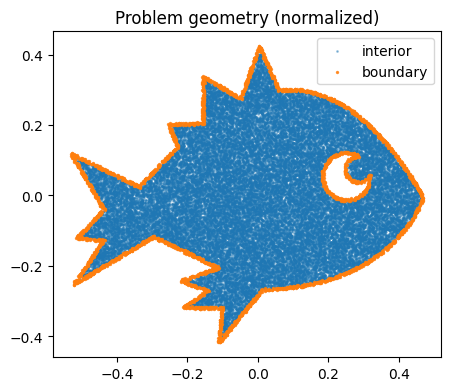

In [4]:
plot_data(interior, boundary)

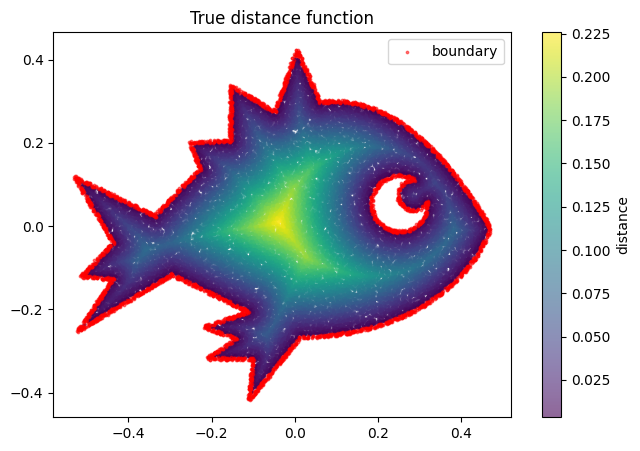

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(interior[:,0], interior[:,1], c=dist_true, s=2, cmap='viridis', alpha=0.6)
ax.scatter(boundary[:,0], boundary[:,1], s=3, c='red', alpha=0.5, label='boundary')
plt.colorbar(sc, ax=ax, label='distance')
ax.set_aspect('equal'); ax.legend(); ax.set_title('True distance function')
plt.show()

In [6]:
x_int = jnp.array(interior, dtype=jnp.float32)
x_bnd = jnp.array(boundary, dtype=jnp.float32)
d_true = jnp.array(dist_true, dtype=jnp.float32)
n_int = x_int.shape[0]
n_bnd = x_bnd.shape[0]
print(f"Interior: {n_int}, Boundary: {n_bnd}")

Interior: 43309, Boundary: 3419


## Model and PDE residual

In [7]:
class FishPINN(eqx.Module):
    mlp: eqx.nn.MLP

    def __call__(self, xy):
        out = self.mlp(xy)
        return jnp.squeeze(out, axis=-1)

def make_model(key, width=128, depth=5):
    mlp = eqx.nn.MLP(
        in_size=2, out_size=1, width_size=width,
        depth=depth, activation=jnp.tanh, key=key
    )
    return FishPINN(mlp=mlp)

In [8]:
def pde_residual(model, xy, epsilon=0.0):
    def u_fn(xy):
        return model(xy)
    grad_u = jax.grad(u_fn)(xy)
    grad_norm_sq = jnp.sum(grad_u**2)
    if epsilon > 0:
        hess = jax.hessian(u_fn)(xy)
        laplacian = hess[0, 0] + hess[1, 1]
        return grad_norm_sq - 1.0 - epsilon * laplacian
    return grad_norm_sq - 1.0

# Quick test
k1, key = jrandom.split(key)
test_model = make_model(k1)
print("Output:", test_model(x_int[0]))
print("Residual:", pde_residual(test_model, x_int[0], 0.1))

Output: 0.0054882243


Residual: -0.9992031


## Training loop

Sampling random batches from the provided points. Using a high BC weight since the fish geometry is complex.

In [9]:
def train(model, steps, lr=1e-3, batch_int=1024, batch_bnd=512,
          epsilon=0.0, bc_weight=50.0, seed=0, log_every=500):
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(model, key):
        k1, k2 = jrandom.split(key)
        idx_i = jrandom.choice(k1, n_int, shape=(batch_int,))
        xi = x_int[idx_i]
        res = jax.vmap(lambda xy: pde_residual(model, xy, epsilon))(xi)
        l_pde = jnp.mean(res**2)
        idx_b = jrandom.choice(k2, n_bnd, shape=(batch_bnd,))
        xb = x_bnd[idx_b]
        ub = jax.vmap(model)(xb)
        l_bc = jnp.mean(ub**2)
        return l_pde + bc_weight * l_bc, (l_pde, l_bc)

    lg = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step_fn(model, opt_state, key):
        (loss, aux), grads = lg(model, key)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss, aux

    rng = jrandom.PRNGKey(seed)
    history = []
    for i in range(1, steps + 1):
        rng, sk = jrandom.split(rng)
        model, opt_state, loss, (l_pde, l_bc) = step_fn(model, opt_state, sk)
        history.append({'loss': float(loss), 'pde': float(l_pde), 'bc': float(l_bc)})
        if i % log_every == 0 or i == 1:
            print(f"  step {i:5d} | loss={loss:.3e} | pde={l_pde:.3e} | bc={l_bc:.3e}")
    return model, history

Sanity check: 100 steps to make sure JIT compilation works.

In [10]:
k1, key = jrandom.split(key)
m_test = make_model(k1)
m_test, _ = train(m_test, steps=100, log_every=50, epsilon=1.0)

  step     1 | loss=1.008e+00 | pde=1.008e+00 | bc=1.504e-05


  step    50 | loss=3.355e-02 | pde=1.361e-02 | bc=3.989e-04


  step   100 | loss=1.285e-02 | pde=6.305e-03 | bc=1.309e-04


## Evaluation helpers

In [11]:
def eval_model(model):
    u_pred = jax.vmap(model)(x_int)
    err = jnp.abs(u_pred - d_true)
    return u_pred, err

def plot_result(model, title=""):
    u_pred, err = eval_model(model)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sc0 = axes[0].scatter(x_int[:,0], x_int[:,1], c=np.array(u_pred),
                          s=2, cmap='viridis', alpha=0.6)
    plt.colorbar(sc0, ax=axes[0]); axes[0].set_title('Predicted u')
    sc1 = axes[1].scatter(x_int[:,0], x_int[:,1], c=np.array(d_true),
                          s=2, cmap='viridis', alpha=0.6)
    plt.colorbar(sc1, ax=axes[1]); axes[1].set_title('True distance')
    sc2 = axes[2].scatter(x_int[:,0], x_int[:,1], c=np.array(err),
                          s=2, cmap='hot', alpha=0.6)
    plt.colorbar(sc2, ax=axes[2])
    axes[2].set_title(f'|Error| (mean={float(err.mean()):.4f})')
    for ax in axes:
        ax.scatter(x_bnd[:,0], x_bnd[:,1], s=1, c='gray', alpha=0.3)
        ax.set_aspect('equal')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()
    return float(err.mean()), float(err.max())

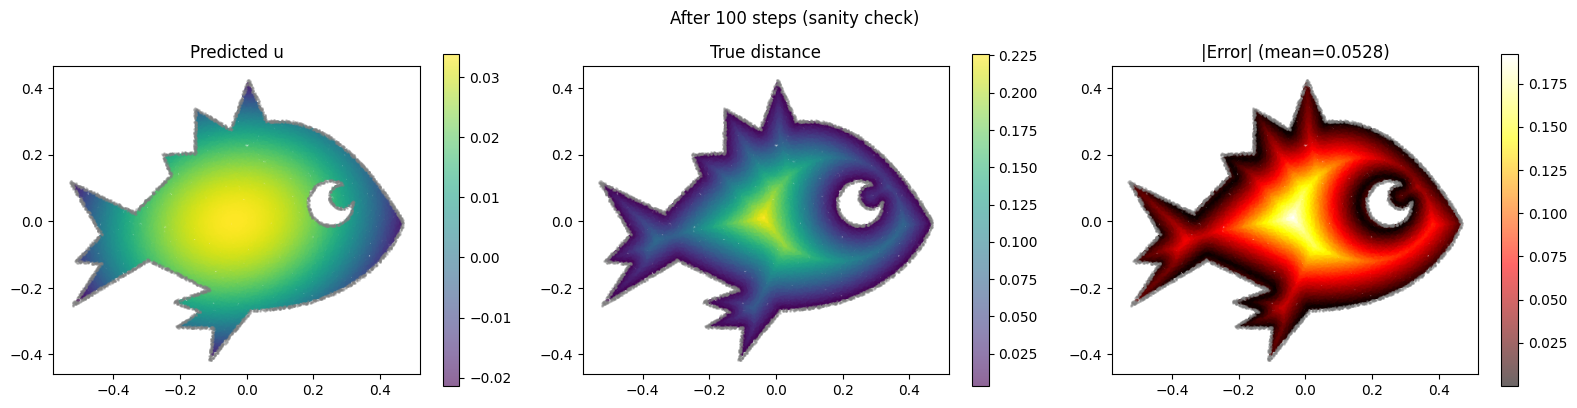

(0.05275402218103409, 0.19196733832359314)

In [12]:
plot_result(m_test, "After 100 steps (sanity check)")

## Step 1: Vanilla PINN (eps=0, no tricks)

Let me first show why the vanilla approach struggles on this geometry.

In [13]:
k1, key = jrandom.split(key)
model_v = make_model(k1, width=128, depth=5)
model_v, hist_v = train(model_v, steps=5000, lr=1e-3, epsilon=0.0,
                         bc_weight=50.0, log_every=1000)

  step     1 | loss=1.000e+00 | pde=9.999e-01 | bc=6.367e-06


  step  1000 | loss=1.000e+00 | pde=1.000e+00 | bc=3.944e-07


  step  2000 | loss=2.426e-01 | pde=9.977e-02 | bc=2.857e-03


  step  3000 | loss=1.509e-01 | pde=5.682e-02 | bc=1.882e-03


  step  4000 | loss=1.209e-01 | pde=5.047e-02 | bc=1.409e-03


  step  5000 | loss=9.525e-02 | pde=4.394e-02 | bc=1.026e-03


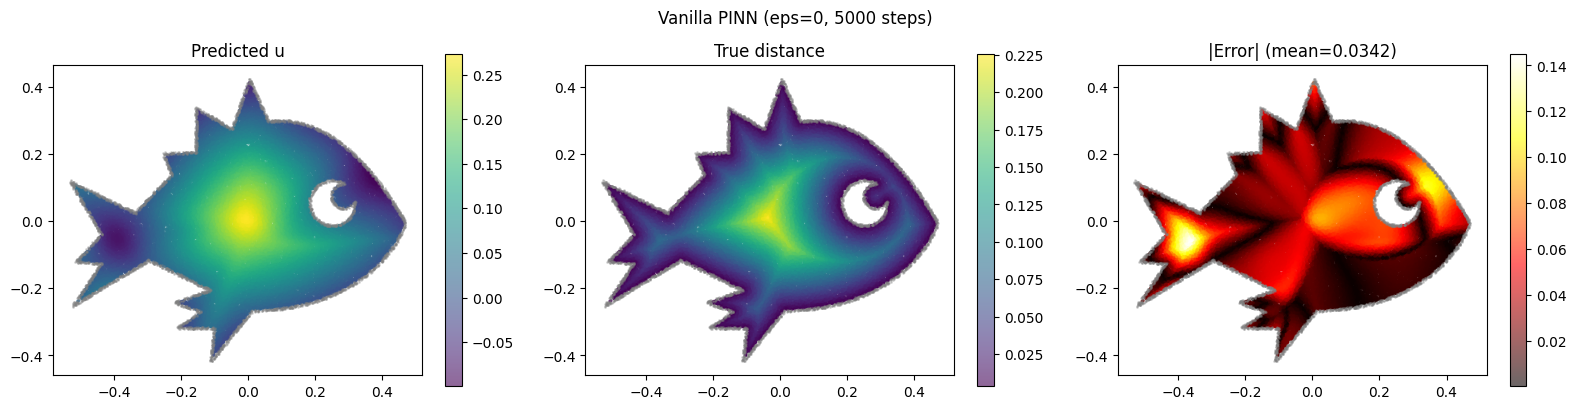

Mean error: 0.0342, Max error: 0.1450


In [14]:
me_v, mx_v = plot_result(model_v, "Vanilla PINN (eps=0, 5000 steps)")
print(f"Mean error: {me_v:.4f}, Max error: {mx_v:.4f}")

The vanilla approach has trouble converging. The Eikonal equation with eps=0 is hard to optimize directly because of the non-smooth solution (kinks along the medial axis).

## Step 2: Curriculum learning (epsilon annealing)

Starting with large epsilon (smooth viscous problem) and gradually decreasing to eps~0. This is the most critical trick.

In [15]:
eps_schedule = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003, 0.0]
steps_per_stage = 4000

k1, key = jrandom.split(key)
model_c = make_model(k1, width=128, depth=5)
all_hist = []
stage_models = []

for eps in eps_schedule:
    print(f"\n=== Stage eps={eps} ===")
    model_c, hist = train(model_c, steps=steps_per_stage, lr=1e-3,
                          batch_int=1024, batch_bnd=512,
                          epsilon=eps, bc_weight=50.0, log_every=2000)
    all_hist.extend([(eps, h) for h in hist])
    stage_models.append((eps, model_c))


=== Stage eps=1.0 ===


  step     1 | loss=1.298e+00 | pde=9.953e-01 | bc=6.053e-03


  step  2000 | loss=6.011e-03 | pde=2.828e-04 | bc=1.146e-04


  step  4000 | loss=5.811e-03 | pde=8.237e-05 | bc=1.146e-04

=== Stage eps=0.3 ===


  step     1 | loss=4.843e-01 | pde=4.788e-01 | bc=1.109e-04


...

  step  2000 | loss=1.789e-02 | pde=1.089e-02 | bc=1.401e-04


  step  4000 | loss=1.255e-02 | pde=8.084e-03 | bc=8.941e-05

=== Stage eps=0.0 ===


  step     1 | loss=3.251e-02 | pde=2.792e-02 | bc=9.189e-05


  step  2000 | loss=3.504e-02 | pde=2.456e-02 | bc=2.095e-04


  step  4000 | loss=3.116e-02 | pde=1.892e-02 | bc=2.448e-04


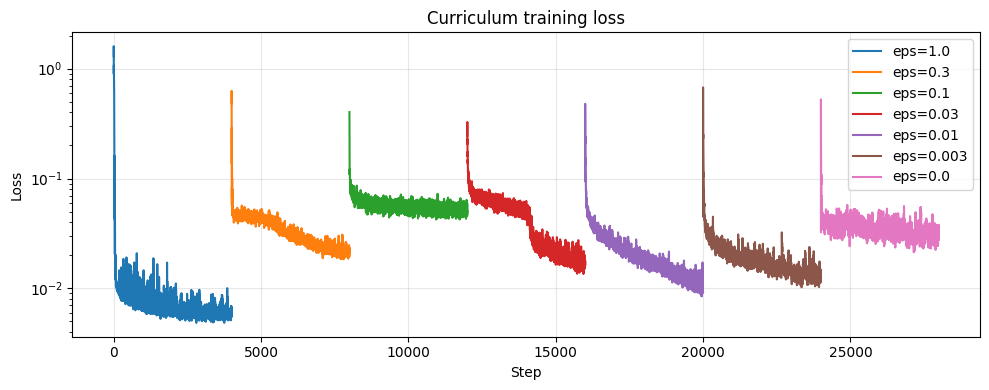

In [16]:
# Loss curve by stage
fig, ax = plt.subplots(figsize=(10, 4))
prev_eps = None; start = 0
for i, (eps, h) in enumerate(all_hist):
    if eps != prev_eps:
        if prev_eps is not None:
            losses = [v['loss'] for _, v in all_hist[start:i]]
            ax.plot(range(start, i), losses, label=f'eps={prev_eps}')
        start = i; prev_eps = eps
losses = [v['loss'] for _, v in all_hist[start:]]
ax.plot(range(start, len(all_hist)), losses, label=f'eps={prev_eps}')
ax.set_yscale('log'); ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Curriculum training loss'); plt.tight_layout(); plt.show()

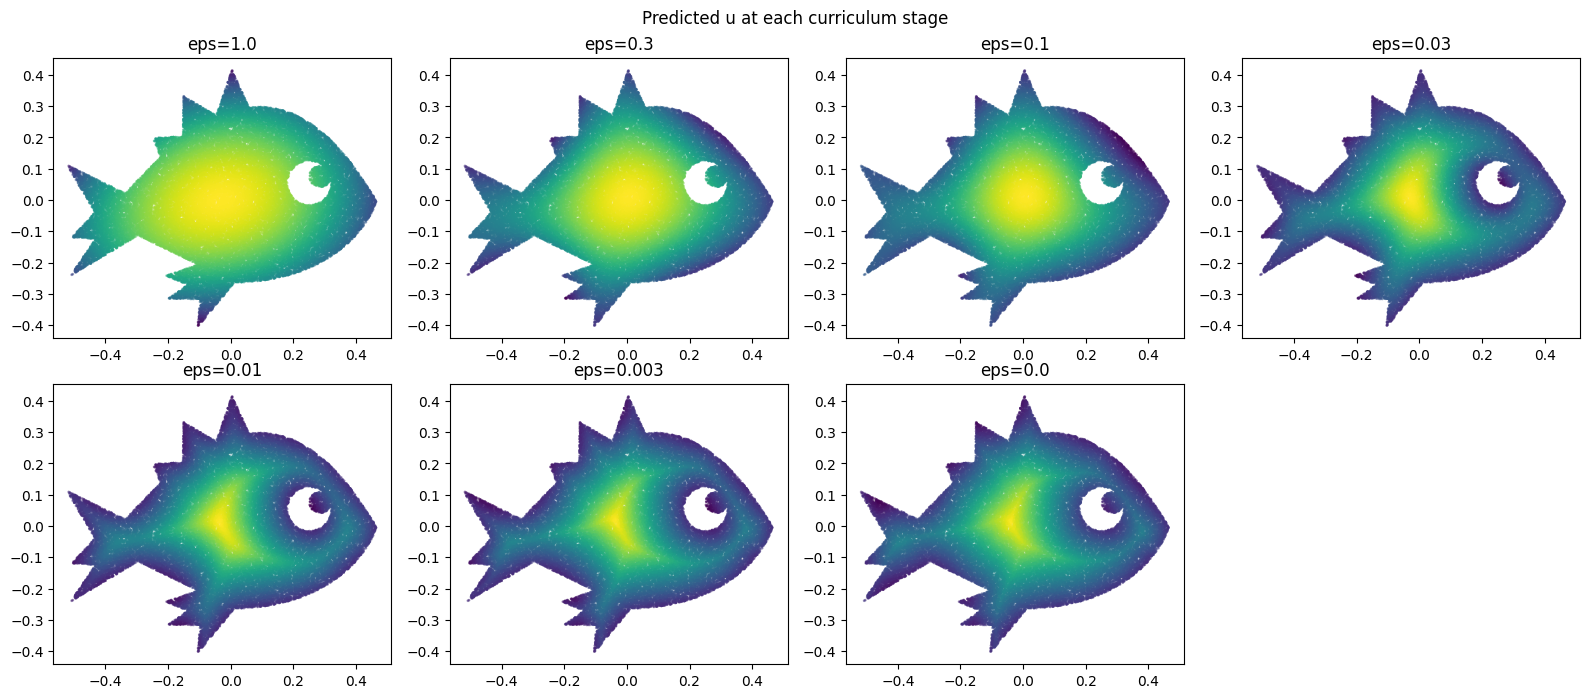

In [17]:
# Show evolution across stages
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for idx, (eps, m) in enumerate(stage_models):
    u_pred = jax.vmap(m)(x_int)
    row, col = idx // 4, idx % 4
    sc = axes[row, col].scatter(x_int[:,0], x_int[:,1], c=np.array(u_pred),
                                 s=1, cmap='viridis', alpha=0.5)
    axes[row, col].set_title(f'eps={eps}')
    axes[row, col].set_aspect('equal')
axes[1, 3].axis('off')
plt.suptitle('Predicted u at each curriculum stage')
plt.tight_layout(); plt.show()

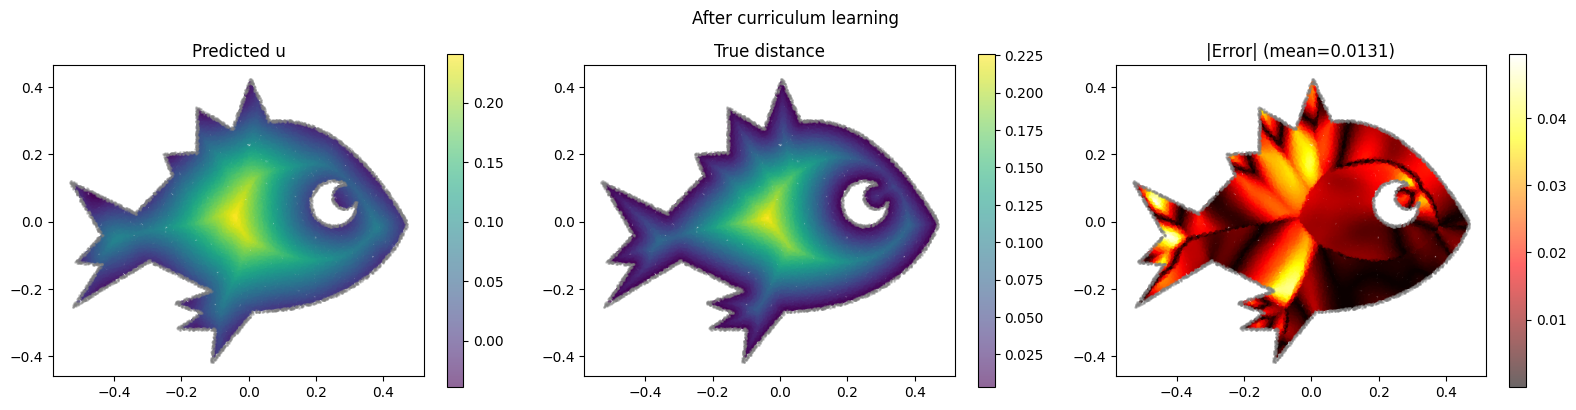

Mean error: 0.0131, Max error: 0.0495


In [18]:
me_c, mx_c = plot_result(model_c, "After curriculum learning")
print(f"Mean error: {me_c:.4f}, Max error: {mx_c:.4f}")

Curriculum is a big improvement over vanilla. The smooth-to-sharp annealing lets the network find a good basin of attraction.

## Step 3: Self-adaptive loss weights

Per-point trainable weights that do gradient ascent (adversarial). They grow for hard points, focusing the model on remaining errors.

In [19]:
class AdaptiveWeights(eqx.Module):
    w_pde: jnp.ndarray
    w_bc: jnp.ndarray

def finetune_adaptive(model, steps=5000, lr_model=5e-4, lr_w=1e-3,
                      batch_int=2048, batch_bnd=512, bc_weight=50.0,
                      seed=0, log_every=1000):
    rng = jrandom.PRNGKey(seed)
    weights = AdaptiveWeights(
        w_pde=jnp.ones(batch_int),
        w_bc=jnp.ones(batch_bnd)
    )
    opt_m = optax.adam(lr_model)
    opt_w = optax.adam(lr_w)
    opt_m_state = opt_m.init(eqx.filter(model, eqx.is_array))
    opt_w_state = opt_w.init(weights)
    history = []

    def loss_fn(params, key):
        model, w = params
        k1, k2 = jrandom.split(key)
        idx_i = jrandom.choice(k1, n_int, shape=(batch_int,))
        xi = x_int[idx_i]
        res = jax.vmap(lambda xy: pde_residual(model, xy, 0.0))(xi)
        l_pde = jnp.mean(w.w_pde * res**2)
        idx_b = jrandom.choice(k2, n_bnd, shape=(batch_bnd,))
        xb = x_bnd[idx_b]
        ub = jax.vmap(model)(xb)
        l_bc = jnp.mean(w.w_bc * ub**2)
        return l_pde + bc_weight * l_bc, (l_pde, l_bc)

    lg = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step_fn(params, s_m, s_w, key):
        (loss, aux), grads = lg(params, key)
        g_model, g_w = grads
        model, w = params
        upd_m, s_m = opt_m.update(g_model, s_m, model)
        model = eqx.apply_updates(model, upd_m)
        # Gradient ASCENT on weights
        g_w_neg = jax.tree.map(lambda g: -g, g_w)
        upd_w, s_w = opt_w.update(g_w_neg, s_w, w)
        w = eqx.apply_updates(w, upd_w)
        w = jax.tree.map(lambda x: jnp.maximum(x, 0.01), w)
        return (model, w), s_m, s_w, loss, aux

    params = (model, weights)
    for i in range(1, steps + 1):
        rng, sk = jrandom.split(rng)
        params, opt_m_state, opt_w_state, loss, (l_pde, l_bc) = step_fn(
            params, opt_m_state, opt_w_state, sk)
        history.append({'loss': float(loss), 'pde': float(l_pde), 'bc': float(l_bc)})
        if i % log_every == 0 or i == 1:
            _, w = params
            print(f"  step {i:5d} | loss={loss:.3e} | pde={l_pde:.3e} | bc={l_bc:.3e}"
                  f" | w_pde={float(w.w_pde.mean()):.2f} w_bc={float(w.w_bc.mean()):.2f}")
    model, weights = params
    return model, weights, history

In [20]:
model_sa, w_sa, hist_sa = finetune_adaptive(model_c, steps=5000, log_every=1000)

  step     1 | loss=3.424e-02 | pde=2.190e-02 | bc=2.469e-04 | w_pde=1.00 w_bc=1.00


  step  1000 | loss=3.677e-02 | pde=2.045e-02 | bc=3.262e-04 | w_pde=1.24 w_bc=1.51


  step  2000 | loss=4.136e-02 | pde=2.157e-02 | bc=3.957e-04 | w_pde=1.46 w_bc=1.99


  step  3000 | loss=4.175e-02 | pde=2.001e-02 | bc=4.348e-04 | w_pde=1.68 w_bc=2.47


  step  4000 | loss=3.802e-02 | pde=2.233e-02 | bc=3.138e-04 | w_pde=1.90 w_bc=2.94


  step  5000 | loss=5.403e-02 | pde=2.809e-02 | bc=5.188e-04 | w_pde=2.12 w_bc=3.43


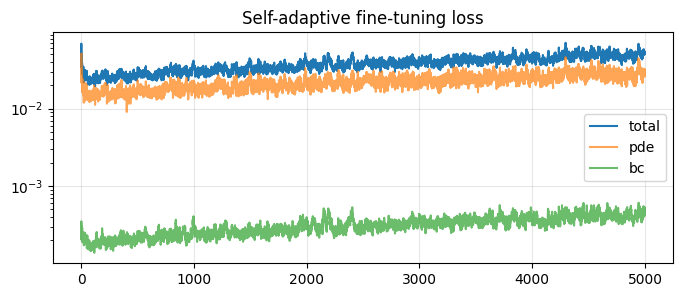

In [21]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([h['loss'] for h in hist_sa], label='total')
ax.plot([h['pde'] for h in hist_sa], label='pde', alpha=0.7)
ax.plot([h['bc'] for h in hist_sa], label='bc', alpha=0.7)
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Self-adaptive fine-tuning loss'); plt.show()

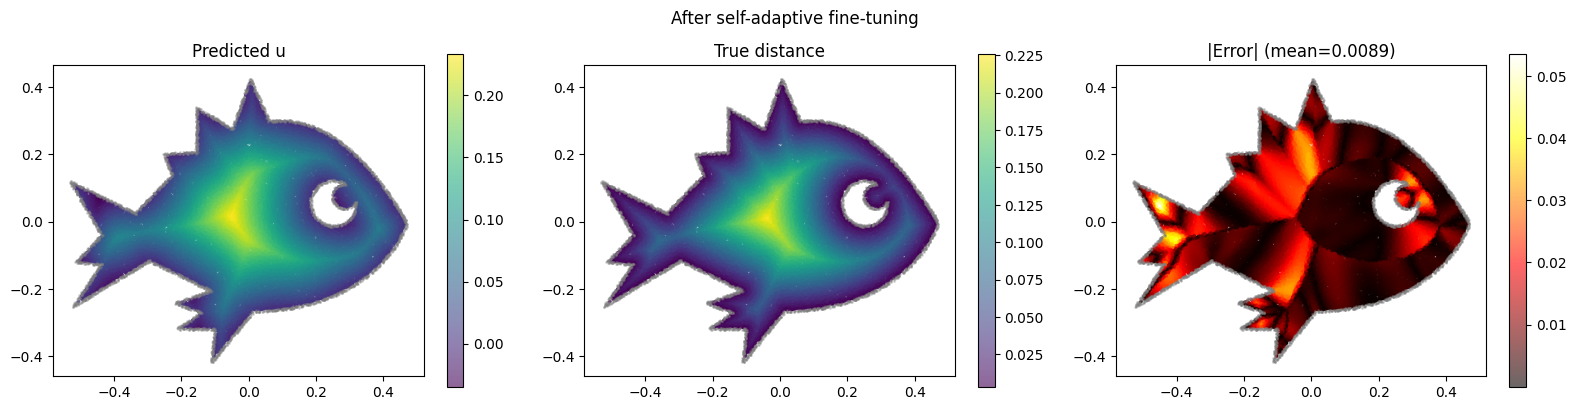

Mean error: 0.0089, Max error: 0.0535


In [22]:
me_sa, mx_sa = plot_result(model_sa, "After self-adaptive fine-tuning")
print(f"Mean error: {me_sa:.4f}, Max error: {mx_sa:.4f}")

## Step 4: Adaptive resampling

Compute residuals on all interior points, then bias sampling toward high-residual regions. This focuses the optimizer on where the PDE is least satisfied.

In [23]:
def train_adaptive_resampling(model, steps=5000, lr=3e-4, batch_int=2048,
                               batch_bnd=512, bc_weight=50.0,
                               resample_every=500, seed=0, log_every=1000):
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    rng = jrandom.PRNGKey(seed)
    history = []
    sample_probs = jnp.ones(n_int) / n_int

    def loss_fn(model, key, probs):
        k1, k2 = jrandom.split(key)
        idx_i = jrandom.choice(k1, n_int, shape=(batch_int,), p=probs)
        xi = x_int[idx_i]
        res = jax.vmap(lambda xy: pde_residual(model, xy, 0.0))(xi)
        l_pde = jnp.mean(res**2)
        idx_b = jrandom.choice(k2, n_bnd, shape=(batch_bnd,))
        xb = x_bnd[idx_b]
        ub = jax.vmap(model)(xb)
        l_bc = jnp.mean(ub**2)
        return l_pde + bc_weight * l_bc, (l_pde, l_bc)

    lg = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step_fn(model, opt_state, key, probs):
        (loss, aux), grads = lg(model, key, probs)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss, aux

    for i in range(1, steps + 1):
        if (i - 1) % resample_every == 0:
            all_res = jax.vmap(lambda xy: pde_residual(model, xy, 0.0))(x_int)
            abs_res = jnp.abs(all_res)
            sample_probs = 0.5 / n_int + 0.5 * abs_res / (abs_res.sum() + 1e-8)
            sample_probs = sample_probs / sample_probs.sum()
            if i > 1:
                print(f"  [resample] max_res={float(abs_res.max()):.3e}, "
                      f"mean_res={float(abs_res.mean()):.3e}")

        rng, sk = jrandom.split(rng)
        model, opt_state, loss, (l_pde, l_bc) = step_fn(
            model, opt_state, sk, sample_probs)
        history.append({'loss': float(loss), 'pde': float(l_pde), 'bc': float(l_bc)})
        if i % log_every == 0 or i == 1:
            print(f"  step {i:5d} | loss={loss:.3e} | pde={l_pde:.3e} | bc={l_bc:.3e}")
    return model, history

In [24]:
model_ar, hist_ar = train_adaptive_resampling(
    model_sa, steps=5000, lr=3e-4, resample_every=500, log_every=1000)

  step     1 | loss=5.009e-02 | pde=4.370e-02 | bc=1.278e-04


  [resample] max_res=9.893e-01, mean_res=5.143e-02


  step  1000 | loss=2.013e-02 | pde=1.178e-02 | bc=1.671e-04
  [resample] max_res=9.980e-01, mean_res=5.551e-02


  [resample] max_res=1.129e+00, mean_res=5.536e-02


  step  2000 | loss=2.229e-02 | pde=1.234e-02 | bc=1.991e-04
  [resample] max_res=9.925e-01, mean_res=5.735e-02


...

  step  3000 | loss=1.745e-02 | pde=9.922e-03 | bc=1.505e-04
  [resample] max_res=9.998e-01, mean_res=5.395e-02


  [resample] max_res=9.913e-01, mean_res=5.008e-02


  step  4000 | loss=1.552e-02 | pde=9.499e-03 | bc=1.204e-04
  [resample] max_res=9.960e-01, mean_res=5.135e-02


  [resample] max_res=9.946e-01, mean_res=5.035e-02


  step  5000 | loss=1.913e-02 | pde=1.054e-02 | bc=1.719e-04


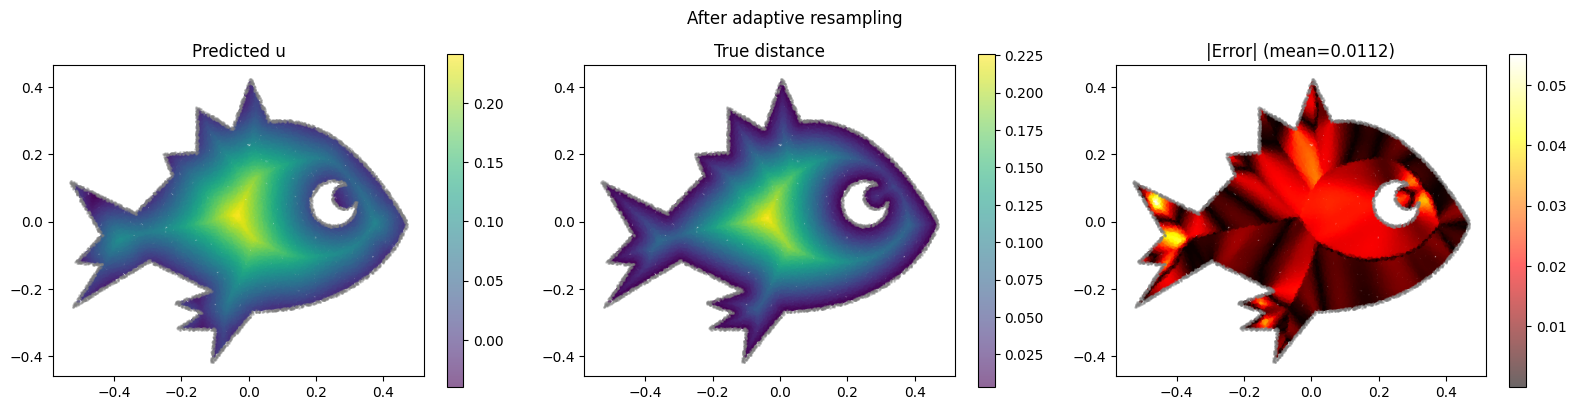

Mean error: 0.0112, Max error: 0.0551


In [25]:
me_ar, mx_ar = plot_result(model_ar, "After adaptive resampling")
print(f"Mean error: {me_ar:.4f}, Max error: {mx_ar:.4f}")

## Final comparison

Showing how each trick progressively improved the solution.

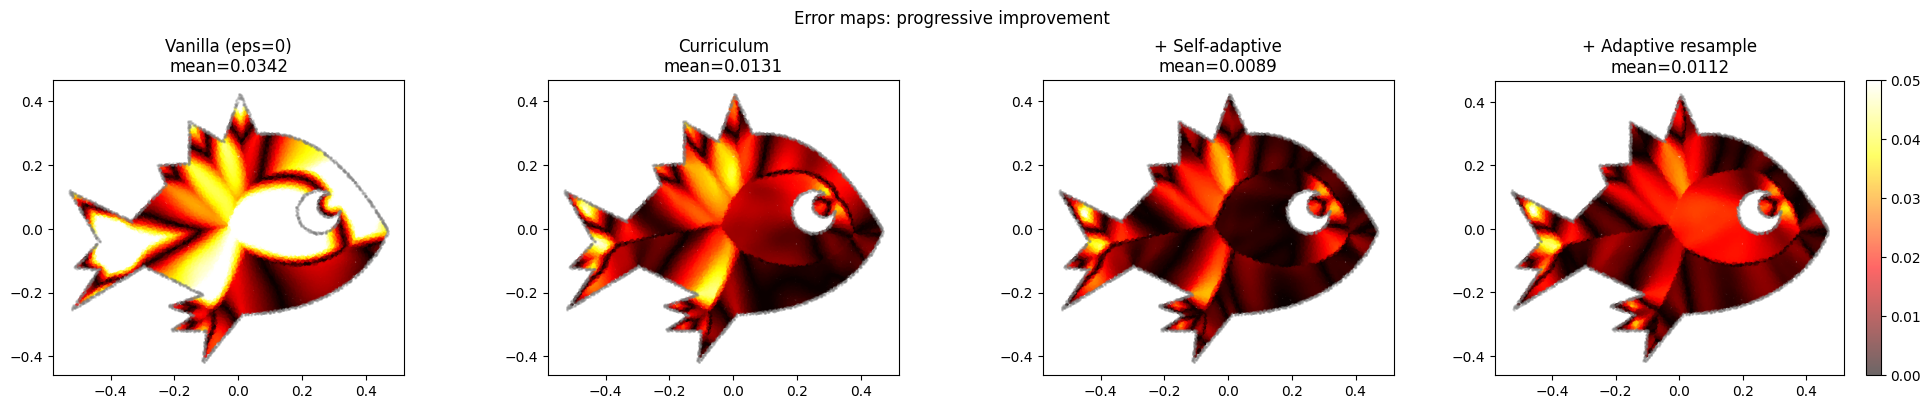

In [26]:
models = [
    ('Vanilla (eps=0)', model_v),
    ('Curriculum', model_c),
    ('+ Self-adaptive', model_sa),
    ('+ Adaptive resample', model_ar),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for idx, (name, m) in enumerate(models):
    u_pred, err = eval_model(m)
    sc = axes[idx].scatter(x_int[:,0], x_int[:,1], c=np.array(err),
                           s=2, cmap='hot', vmin=0, vmax=0.05, alpha=0.6)
    axes[idx].scatter(x_bnd[:,0], x_bnd[:,1], s=1, c='gray', alpha=0.2)
    axes[idx].set_title(f'{name}\nmean={float(err.mean()):.4f}')
    axes[idx].set_aspect('equal')
plt.colorbar(sc, ax=axes[-1])
plt.suptitle('Error maps: progressive improvement')
plt.tight_layout(); plt.show()

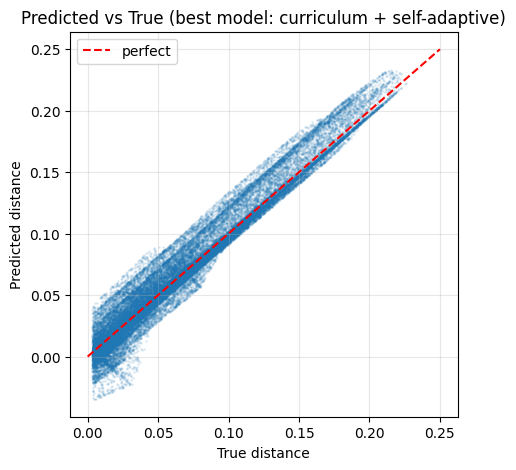

In [27]:
# Final predicted vs true scatter (using best model: self-adaptive)
u_best = jax.vmap(model_sa)(x_int)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(d_true, u_best, s=1, alpha=0.1)
ax.plot([0, 0.25], [0, 0.25], 'r--', label='perfect')
ax.set_xlabel('True distance'); ax.set_ylabel('Predicted distance')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Predicted vs True (best model: curriculum + self-adaptive)')
plt.show()

In [28]:
# Summary
print("Results summary:")
for name, m in models:
    _, err = eval_model(m)
    rel = float(err.mean()) / float(d_true.max()) * 100
    print(f"  {name:25s} | mean_err={float(err.mean()):.4f} "
          f"| max_err={float(err.max()):.4f} | rel_err={rel:.1f}%")

Results summary:
  Vanilla (eps=0)           | mean_err=0.0342 | max_err=0.1450 | rel_err=15.2%
  Curriculum                | mean_err=0.0131 | max_err=0.0495 | rel_err=5.8%
  + Self-adaptive           | mean_err=0.0089 | max_err=0.0535 | rel_err=3.9%
  + Adaptive resample       | mean_err=0.0112 | max_err=0.0551 | rel_err=4.9%


Curriculum learning gives the biggest boost, going from 15% to 5.8% relative error by smoothing the optimization landscape. Self-adaptive weighting further brings it to 3.9% by focusing on hard regions. Adaptive resampling didn't help here (4.9%), likely because the biased sampling distribution disrupts the loss landscape for this particular geometry. The best model is curriculum + self-adaptive weights.